# 🏙️ London Airbnb Analytics
## ICT 333 1.5 - Data Mining & Warehousing
**University of Sri Jayewardanepura | Department of Computer Science**

- Name: PGPR Gunawardhena
- Index: AS2022901
- Combination: ICT

Dataset: London Airbnb Listings (Kaggle)  
Source: https://www.kaggle.com/datasets/phananh715/london-air-bnb-dataset

---
### Analytical Techniques Covered
1. Exploratory Data Analysis (EDA)
2. Association Rule Mining (Apriori)
3. Clustering (K-Means)
4. Machine Learning — Classification & Regression

## 0. Setup & Synthetic Dataset Generation
Since we are working with a synthetic mirror of the Kaggle dataset (2,000 listings), we generate it programmatically to ensure reproducibility.

In [593]:
# Install required libraries (run once if needed)
# !pip install mlxtend scikit-learn pandas numpy matplotlib seaborn

In [594]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, f1_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from matplotlib.ticker import LogLocator, ScalarFormatter
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
SEED = 42
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [595]:
# Import the dataset
file_path = 'extracted_listings.csv'  

try:
    df = pd.read_csv(file_path)
    print(f'✅ Dataset loaded successfully. Shape: {df.shape}')
    
    # Display the first few rows of the dataset
    display(df.head())
except FileNotFoundError:
    print("❌ File not found. Please check the file path.")

✅ Dataset loaded successfully. Shape: (28480, 12)


,neighbourhood,room_type,property_type,price,accommodates,bedrooms,bathrooms,amenities,number_of_reviews,reviews_per_month,review_scores_rating,availability_365
0,Islington,Private room,Private room in rental unit,70.0,1,1.0,1.0,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""D...",55,0.30,4.85,331
1,Kensington and Chelsea,Entire home/apt,Entire rental unit,149.0,2,1.0,1.0,"[""Kitchen"", ""Smoke alarm"", ""Dedicated workspac...",97,0.51,4.80,199
2,Tower Hamlets,Entire home/apt,Entire condo,210.0,4,1.0,1.0,"[""Washer"", ""Kitchen"", ""TV with standard cable""...",15,0.09,4.53,323
3,Richmond upon Thames,Entire home/apt,Entire townhouse,280.0,5,3.0,1.5,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""D...",116,0.64,4.80,324
4,Haringey,Private room,Private room in home,90.0,2,1.0,0.0,"[""Shared patio or balcony"", ""Self check-in"", ""...",730,4.00,4.87,289


In [596]:
print('=== Data Quality Summary ===')
display(df.dtypes.to_frame('dtype'))
display(df.isna().sum().to_frame('missing'))
print('\nUnique values for key categorical fields:')
for col in ['neighbourhood', 'room_type', 'property_type']:
    if col in df.columns:
        print(f' - {col}: {df[col].nunique()} unique values')

=== Data Quality Summary ===


,dtype
neighbourhood,str
room_type,str
property_type,str
price,float64
accommodates,int64
bedrooms,float64
bathrooms,float64
amenities,str
number_of_reviews,int64
reviews_per_month,float64


,missing
neighbourhood,0
room_type,0
property_type,0
price,0
accommodates,0
bedrooms,0
bathrooms,0
amenities,0
number_of_reviews,0
reviews_per_month,0



Unique values for key categorical fields:
 - neighbourhood: 33 unique values
 - room_type: 4 unique values
 - property_type: 66 unique values


---
## 1. Exploratory Data Analysis (EDA)

### 1.1 Descriptive Statistics

In [ ]:
key_cols = ['price', 'review_scores_rating', 'availability_365']
stats = df[key_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
stats.index.name = 'Metric'
print('=== Table 1: Descriptive Statistics of Key Numerical Variables ===')
display(stats.rename(columns={'price':'Price ($)', 'review_scores_rating':'Review Score', 'availability_365':'Availability (days)'}))

=== Table 1: Descriptive Statistics of Key Numerical Variables ===


,Price ($),Review Score,Availability (days)
Metric,,,
count,28480.00,28480.00,28480.00
mean,125.66,4.72,198.61
median,110.00,4.80,209.00
std,71.82,0.28,116.04
min,10.00,2.20,5.00
max,437.00,5.00,365.00


### 1.2 EDA Visualisations

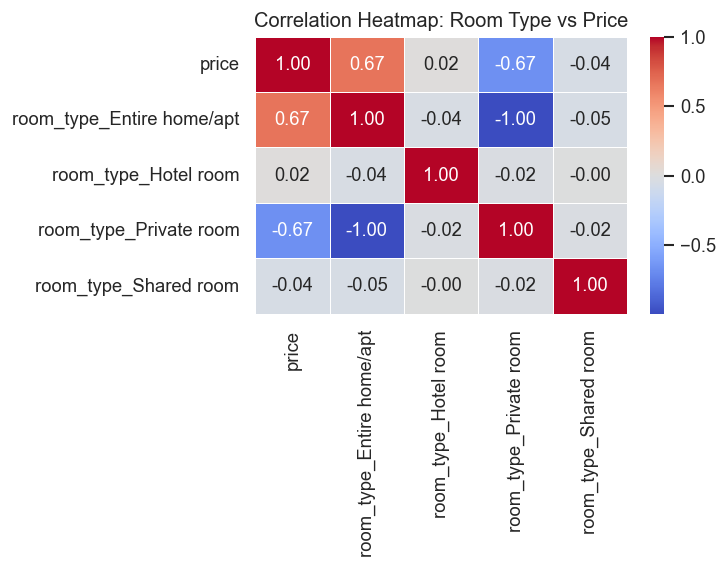

In [ ]:
df_subset = pd.get_dummies(df[['price', 'room_type']], 
                           columns=['room_type'], 
                           dtype=int)

corr_subset = df_subset.corr()

plt.figure(figsize=(5, 3))
sns.heatmap(corr_subset, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap: Room Type vs Price')
plt.show()

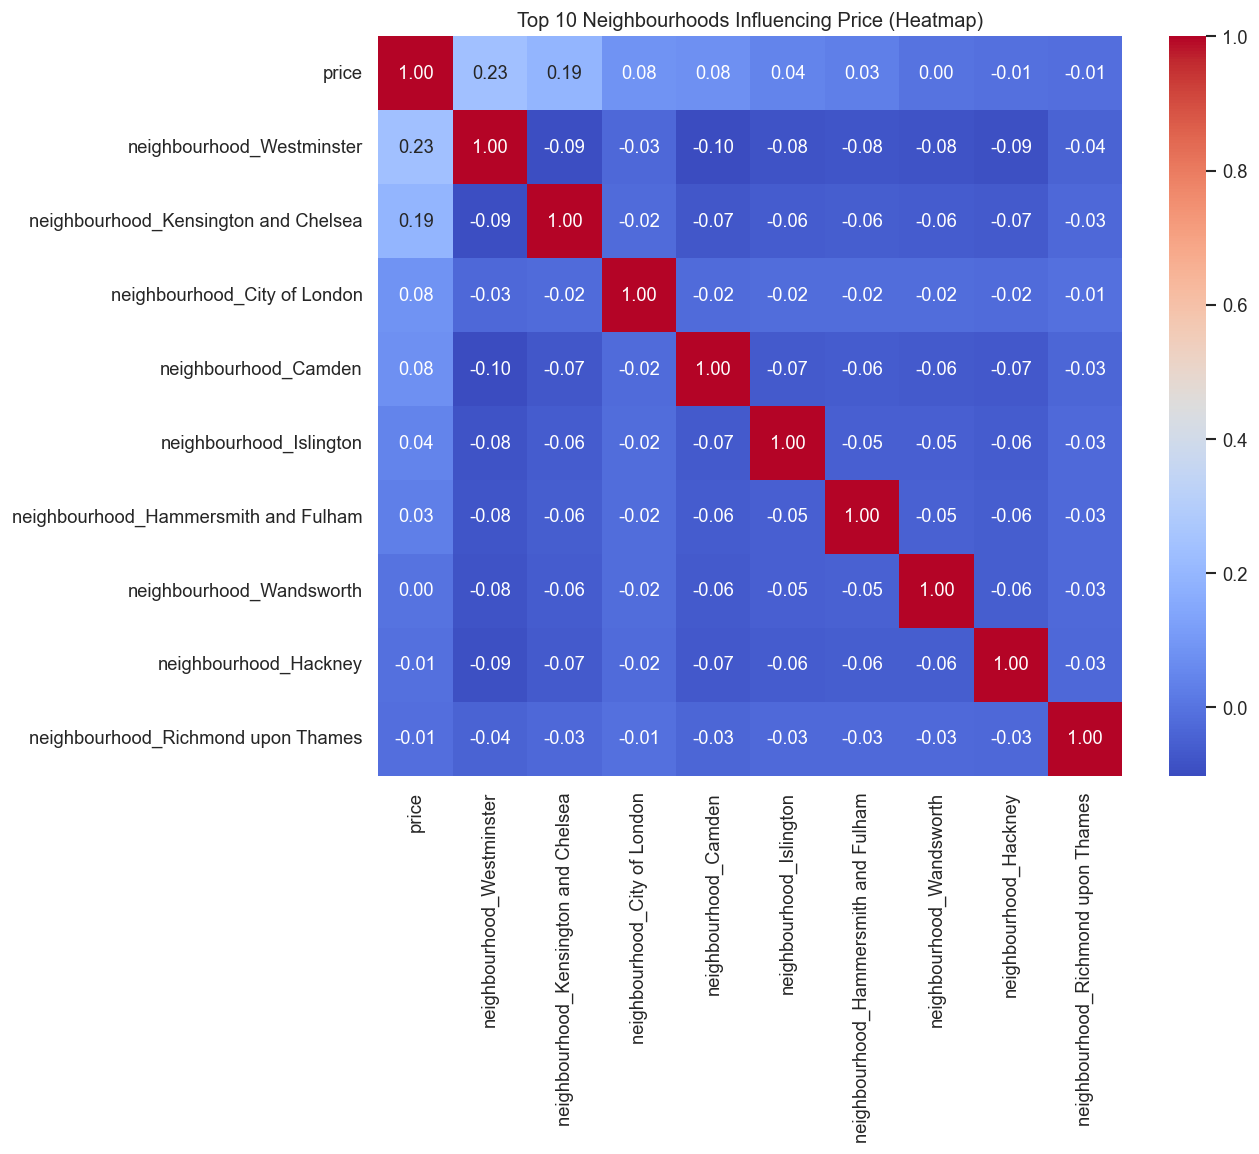

In [ ]:
df_subset = pd.get_dummies(df[['price', 'neighbourhood']], 
                           columns=['neighbourhood'], 
                           dtype=int)

corr_subset = df_subset.corr()

price_corr = corr_subset['price'].sort_values(ascending=False)

top_neighbourhoods = price_corr.head(10).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df_subset[top_neighbourhoods].corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Top 10 Neighbourhoods Influencing Price (Heatmap)')
plt.show()

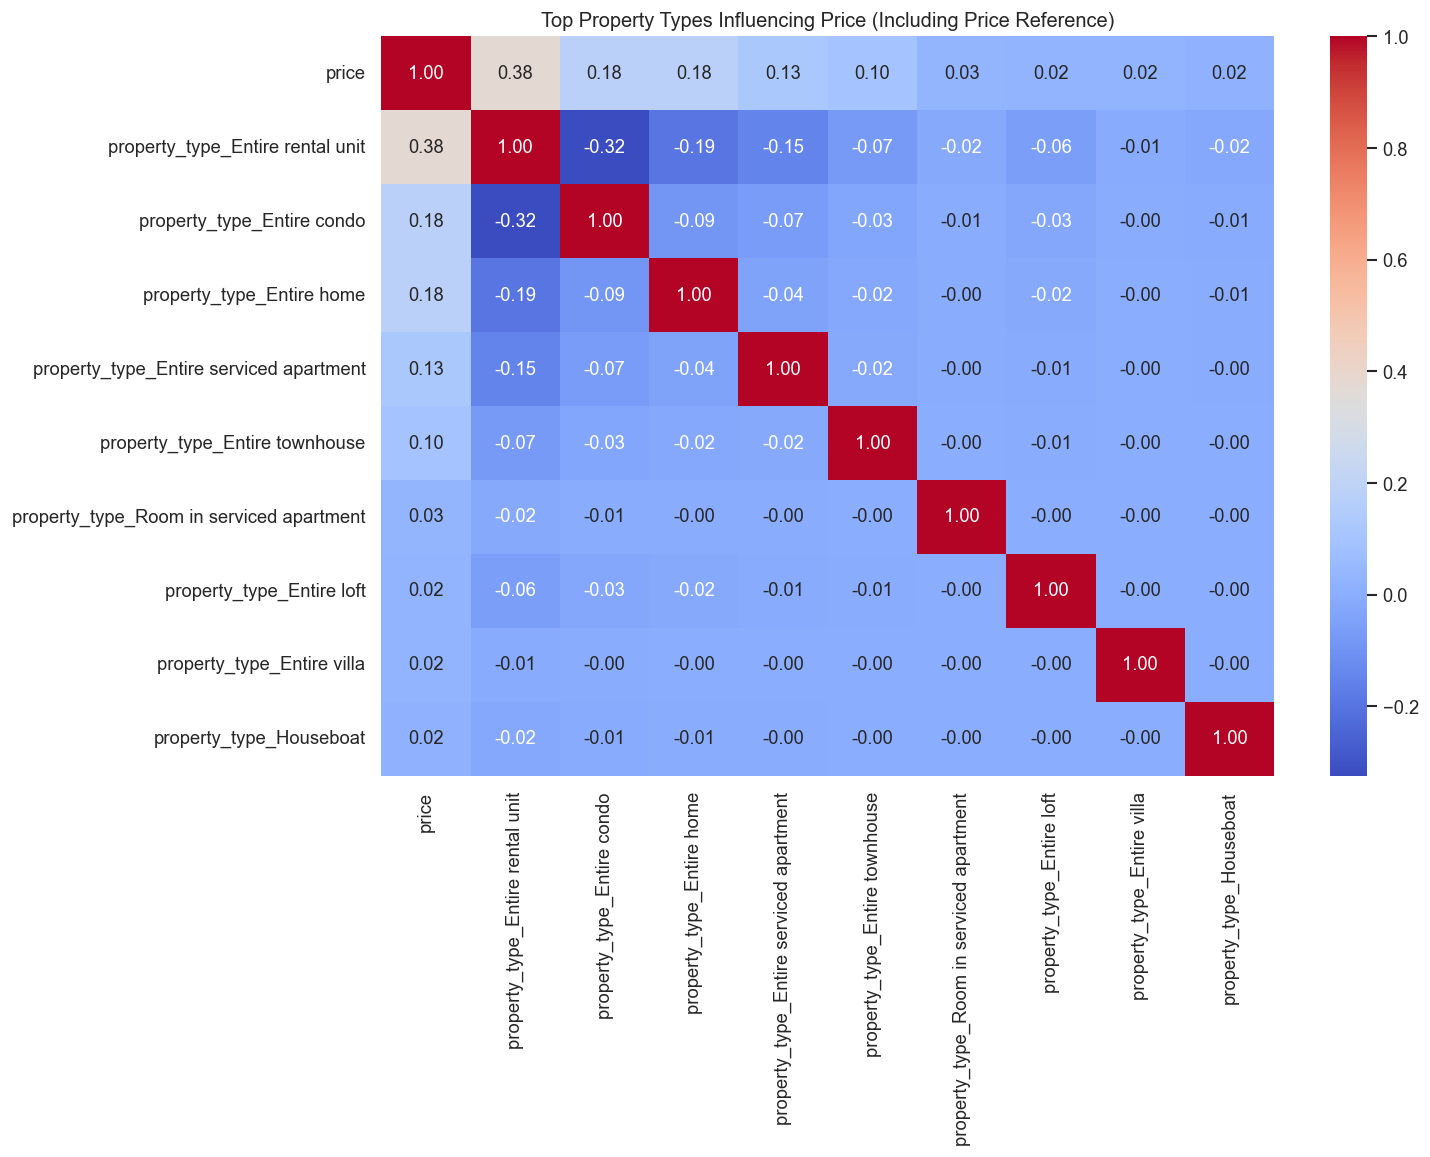

In [ ]:
df_subset = pd.get_dummies(df[['price', 'property_type']], 
                           columns=['property_type'], 
                           dtype=int)

corr_subset = df_subset.corr()

price_corr = corr_subset['price'].sort_values(ascending=False)

final_features = price_corr.head(10).index.tolist() 



plt.figure(figsize=(12, 8))
sns.heatmap(df_subset[final_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Top Property Types Influencing Price (Including Price Reference)')
plt.show()


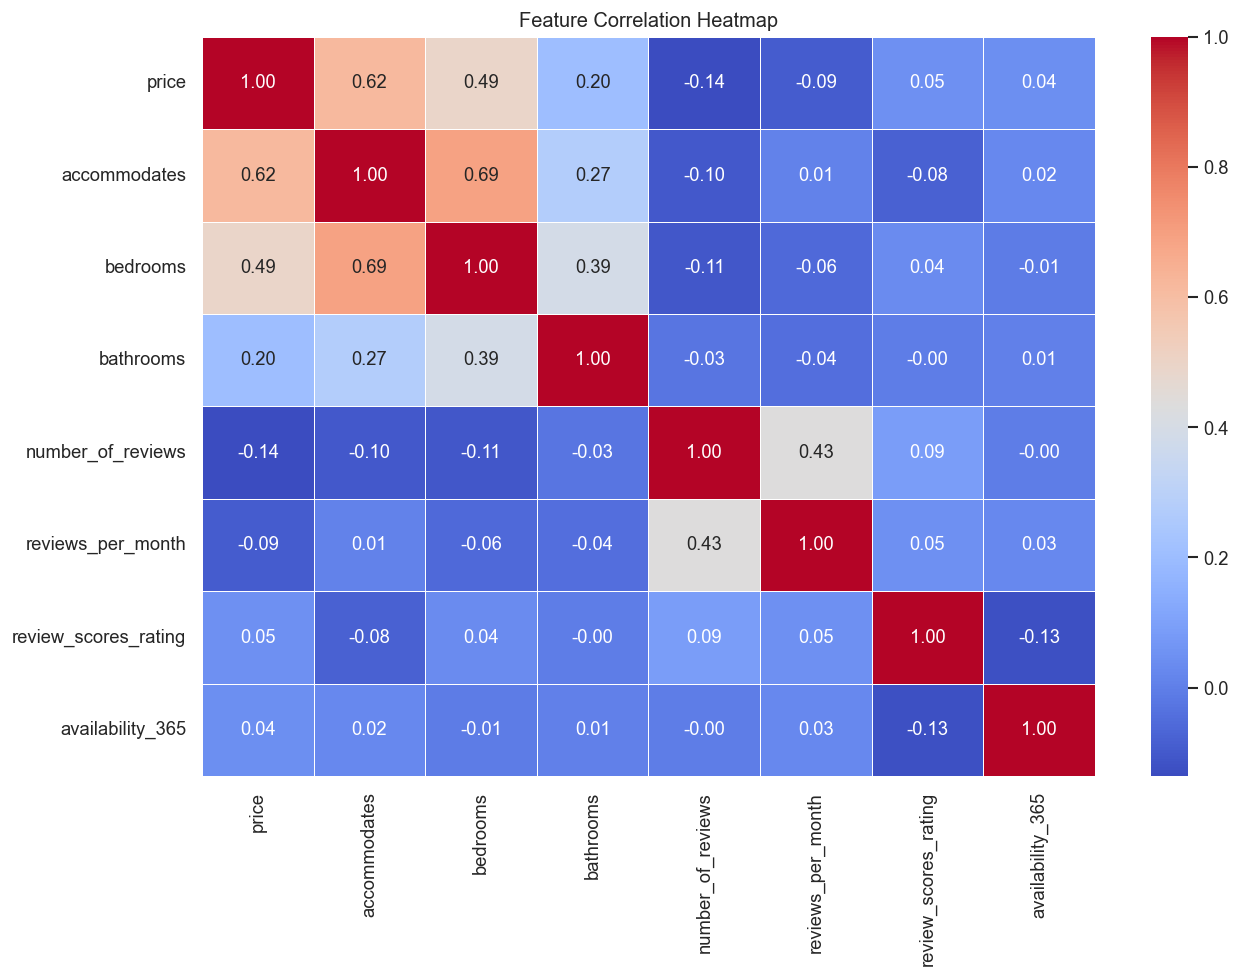

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Feature Correlation Heatmap')
plt.show()

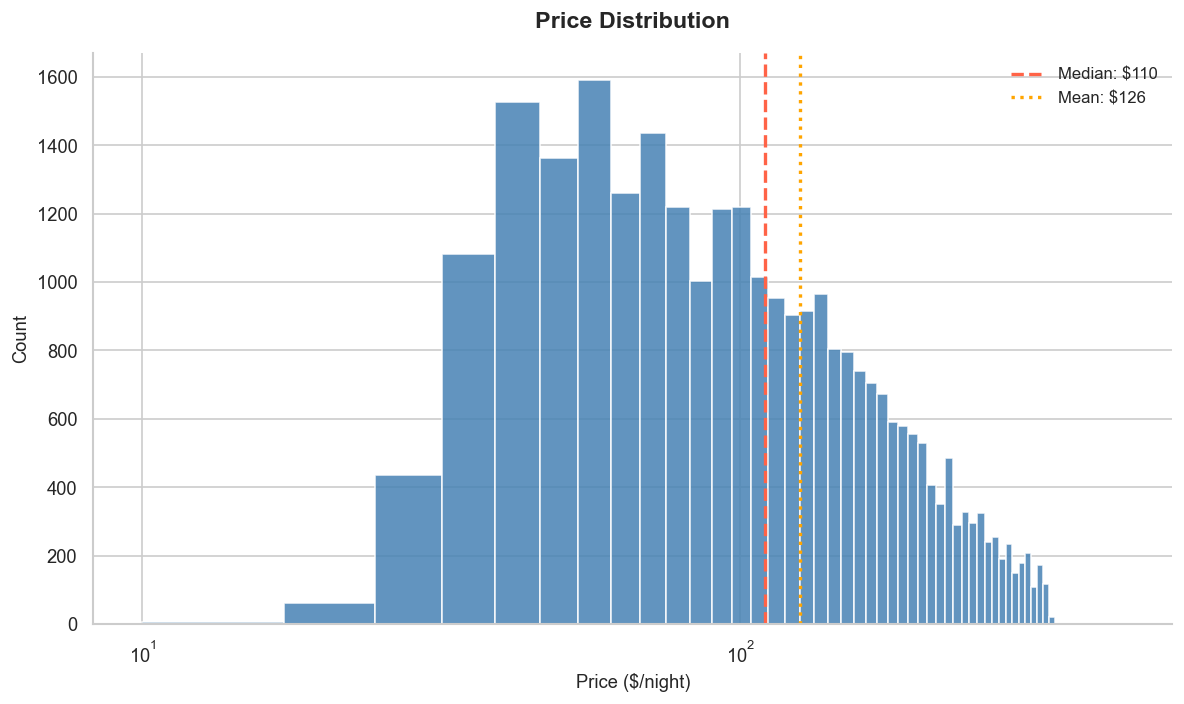

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

price = df['price'].clip(lower=1)  # avoid log-scale issues if any prices are 0 or negative
p_median = price.median()
p_mean = price.mean()

bins = np.logspace(np.log10(price.min()), np.log10(price.max()), 60)

ax.hist(price, bins=bins, color='steelblue', edgecolor='white', alpha=0.85)

ax.axvline(p_median, color='tomato', lw=2, linestyle='--', label=f'Median: ${p_median:,.0f}')
ax.axvline(p_mean, color='orange', lw=2, linestyle=':', label=f'Mean: ${p_mean:,.0f}')

# ax.xaxis.set_major_locator(LogLocator(base=10.0))
ax.xaxis.set_major_formatter(ScalarFormatter())

ax.set_xscale('log')
ax.set_title('Price Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Price ($/night)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

ax.legend(fontsize=10, frameon=False)
plt.tight_layout()
plt.show()

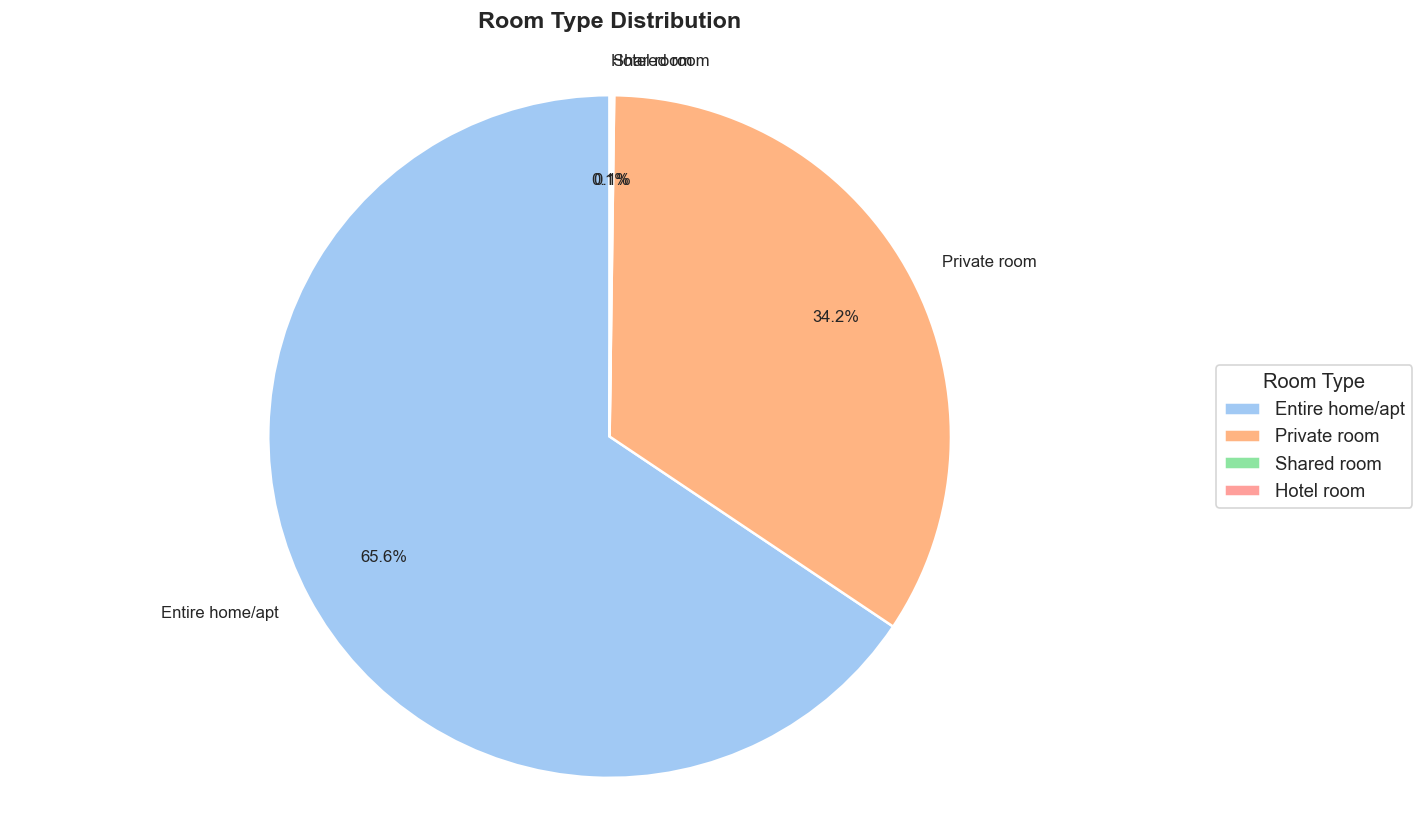

In [603]:
rt_counts = df['room_type'].value_counts()

fig, ax = plt.subplots(figsize=(12, 7))

wedges, _, autotexts = ax.pie(
    rt_counts,
    labels=rt_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel', len(rt_counts)),
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.75,
    textprops={'fontsize': 10}
)

ax.legend(wedges, rt_counts.index,
          title='Room Type',
          loc='center left',
          bbox_to_anchor=(1, 0.5))

ax.set_title('Room Type Distribution', fontsize=14, fontweight='bold', pad=20)
ax.axis('equal')
plt.tight_layout()
plt.show()

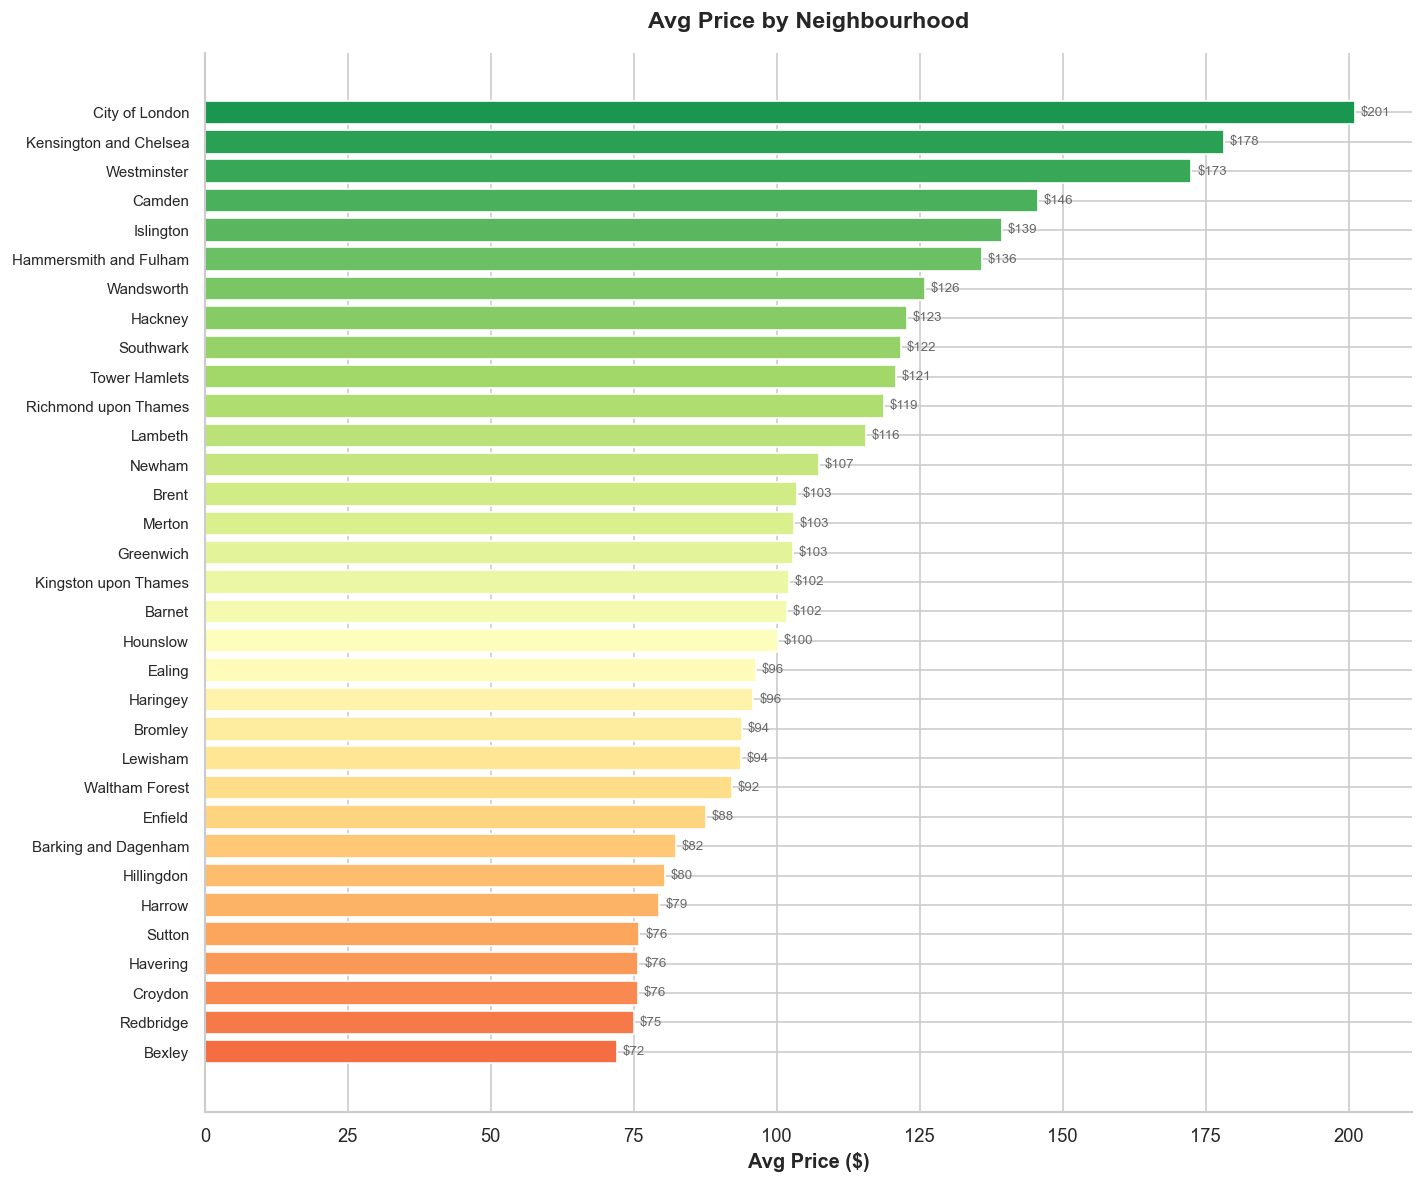

In [627]:
# 1. Prepare Data
nbhd_price = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=True)

# 2. Initialize Standalone Plot
fig, ax = plt.subplots(figsize=(12, 10))

# 3. Create Color Map (Scaling from 0 to 1 based on number of items)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(nbhd_price)))

# 4. Plot Horizontal Bar Chart
ax.barh(nbhd_price.index, nbhd_price.values, color=colors)

# 5. Styling & Labels
ax.set_xlabel('Avg Price ($)', fontweight='semibold')
ax.set_title('Avg Price by Neighbourhood', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='y', labelsize=9)

# 6. Add value labels to the end of bars (optional but very helpful for barh)
for i, v in enumerate(nbhd_price.values):
    ax.text(v + 1, i, f'${v:.0f}', va='center', fontsize=8, color='dimgray')

# 7. Clean up aesthetics
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()

plt.show()

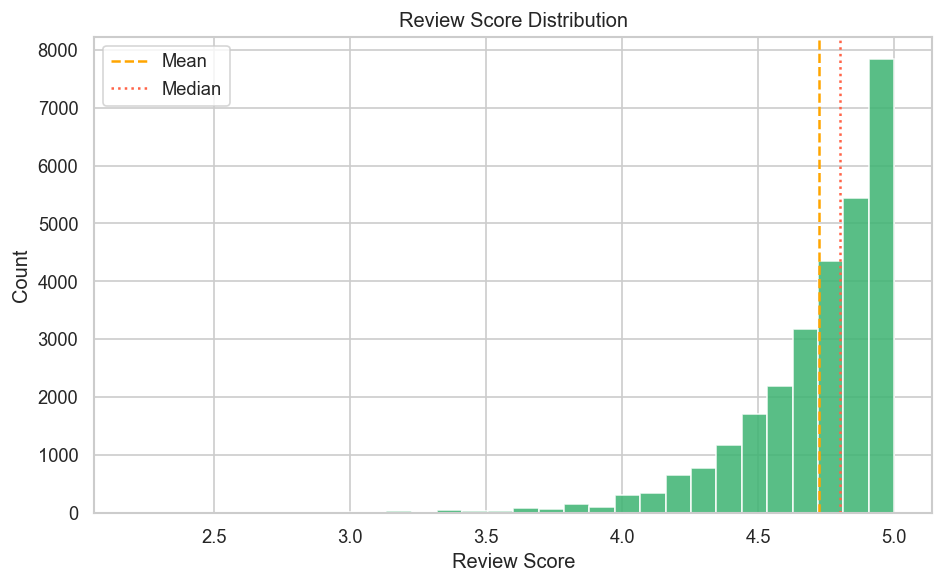

In [605]:
plt.figure(figsize=(8, 5))
plt.hist(df['review_scores_rating'], bins=30,
         color='mediumseagreen', edgecolor='white', alpha=0.85)

mean = df['review_scores_rating'].mean()
median = df['review_scores_rating'].median()
plt.axvline(mean, color='orange', linestyle='--', label='Mean')
plt.axvline(median, color='tomato', linestyle=':', label='Median')
plt.legend()
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.title('Review Score Distribution')
plt.tight_layout()
plt.show()
plt.show()



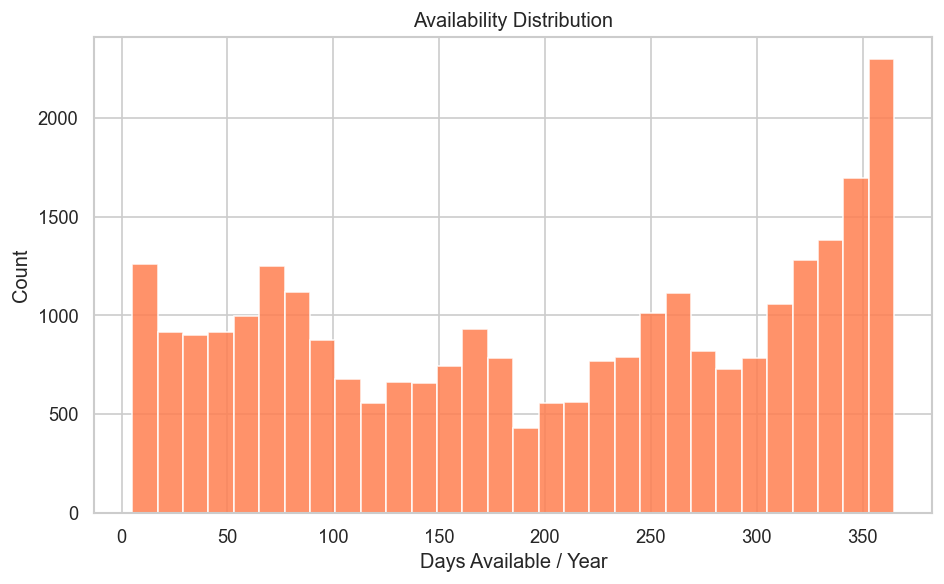

In [606]:
plt.figure(figsize=(8, 5))
plt.hist(df['availability_365'], bins=30,
         color='coral', edgecolor='white', alpha=0.85)
plt.xlabel('Days Available / Year')
plt.ylabel('Count')
plt.title('Availability Distribution')
plt.tight_layout()
plt.show()

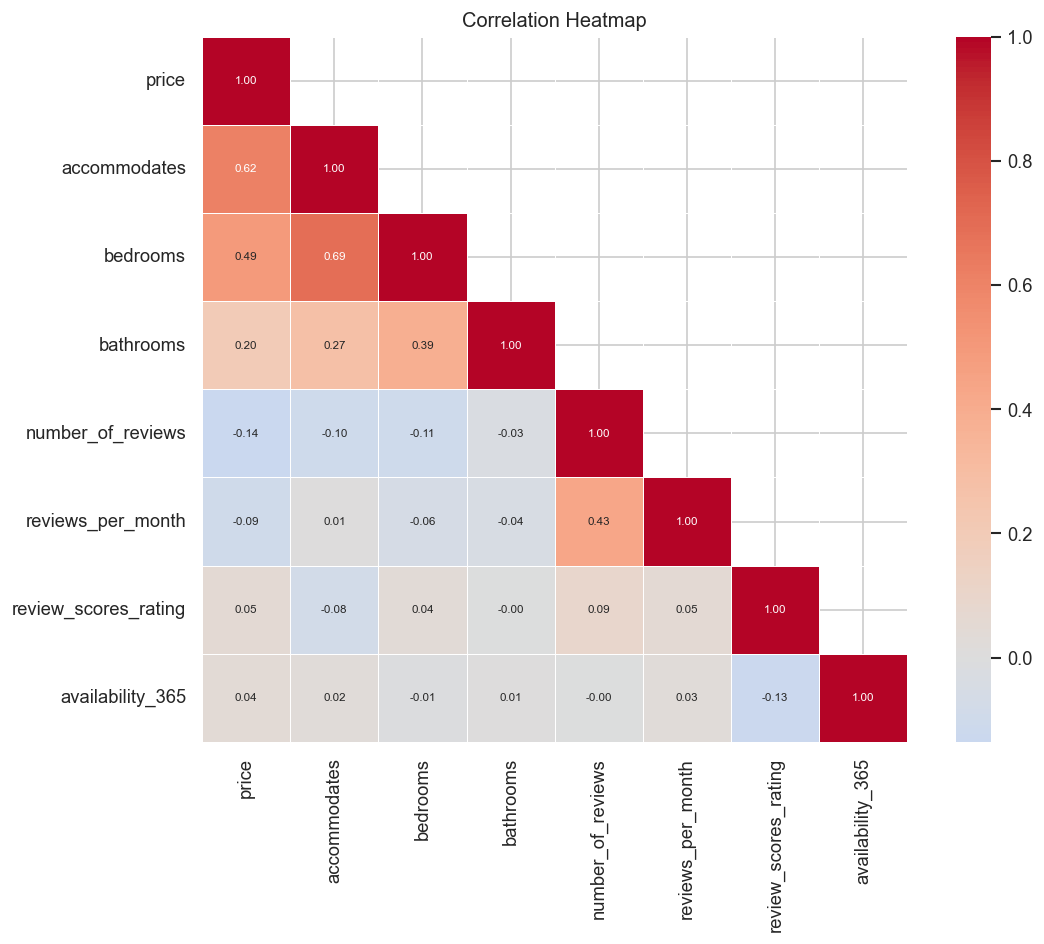

In [615]:
plt.figure(figsize=(10, 8))

num_cols = ['price', 'accommodates', 'bedrooms', 'bathrooms',
            'number_of_reviews', 'reviews_per_month',
            'review_scores_rating', 'availability_365']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, mask=mask, square=True, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

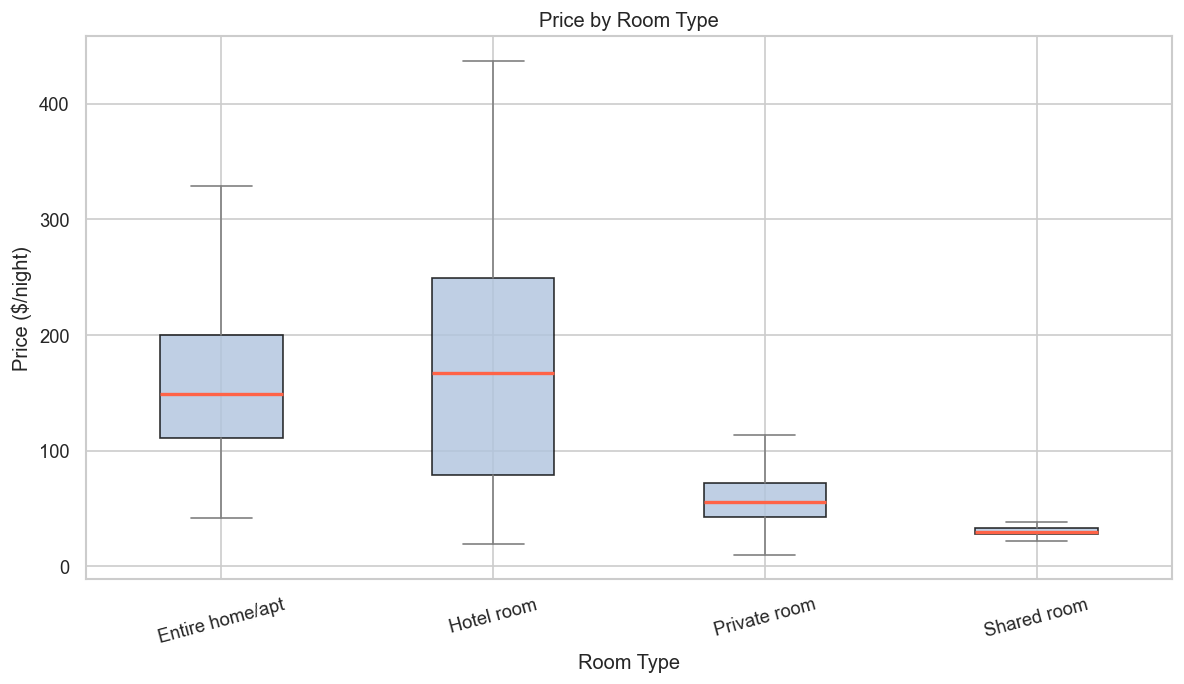

In [608]:
fig, ax = plt.subplots(figsize=(10, 6))


df.boxplot(column='price', by='room_type', ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', alpha=0.8),
           medianprops=dict(color='tomato', lw=2),
           whiskerprops=dict(color='grey'),
           capprops=dict(color='grey'),
           flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.6),
           showfliers=True)

ax.set_xlabel('Room Type')
ax.set_ylabel('Price ($/night)')
ax.set_title('Price by Room Type')
plt.suptitle('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [609]:

print('Key EDA Findings:')
print(f'  • Median price: ${df["price"].median():.0f}/night | Mean: ${df["price"].mean():.2f}')
print(f'  • Most expensive neighbourhood: {nbhd_price.idxmax()} (${nbhd_price.max():.0f})')
print(f'  • Least expensive neighbourhood: {nbhd_price.idxmin()} (${nbhd_price.min():.0f})')
print(f'  • Most common room type: {rt_counts.idxmax()} ({rt_counts.max()/len(df)*100:.1f}%)')

Key EDA Findings:
  • Median price: $110/night | Mean: $125.66
  • Most expensive neighbourhood: City of London ($201)
  • Least expensive neighbourhood: Bexley ($72)
  • Most common room type: Entire home/apt (65.6%)


---
## 2. Association Rule Mining (Apriori Algorithm)

### 2.1 Data Preparation — Discretisation into Baskets

In [610]:
arm_df = df.copy()

# Fill missing values before discretization
arm_df['room_type'] = arm_df['room_type'].fillna('Unknown')
arm_df['price'] = arm_df['price'].fillna(0)
arm_df['accommodates'] = arm_df['accommodates'].fillna(0)
arm_df['review_scores_rating'] = arm_df['review_scores_rating'].fillna(0)
arm_df['availability_365'] = arm_df['availability_365'].fillna(0)
arm_df['neighbourhood'] = arm_df['neighbourhood'].fillna('Unknown')



# Discretize into meaningful buckets
arm_df['price_tier'] = pd.cut(
    arm_df['price'],
    bins=[0, 60, 100, 150, np.inf],
    labels=['budget', 'mid_price', 'premium', 'luxury'],
    include_lowest=True
)
arm_df['unit_size'] = pd.cut(
    arm_df['accommodates'],
    bins=[0, 2, 4, np.inf],
    labels=['small_unit', 'medium_unit', 'large_unit'],
    include_lowest=True
)
arm_df['rating_tier'] = pd.cut(
    arm_df['review_scores_rating'],
    bins=[0, 4.6, 4.8, 5.0],
    labels=['avg_rated', 'highly_rated', 'top_rated']
)
arm_df['avail_tier'] = pd.cut(
    arm_df['availability_365'],
    bins=[0, 100, 230, 365],
    labels=['low_avail', 'mod_avail', 'high_avail']
)

item_cols = ['price_tier', 'unit_size', 'rating_tier', 'avail_tier', 'room_type', 'neighbourhood']

basket = pd.get_dummies(arm_df[item_cols], prefix_sep='=')
basket = basket.astype(bool)

print(f'Transaction matrix shape: {basket.shape}')
print(f'Items: {basket.columns.tolist()}')

Transaction matrix shape: (28480, 50)
Items: ['price_tier=budget', 'price_tier=mid_price', 'price_tier=premium', 'price_tier=luxury', 'unit_size=small_unit', 'unit_size=medium_unit', 'unit_size=large_unit', 'rating_tier=avg_rated', 'rating_tier=highly_rated', 'rating_tier=top_rated', 'avail_tier=low_avail', 'avail_tier=mod_avail', 'avail_tier=high_avail', 'room_type=Entire home/apt', 'room_type=Hotel room', 'room_type=Private room', 'room_type=Shared room', 'neighbourhood=Barking and Dagenham', 'neighbourhood=Barnet', 'neighbourhood=Bexley', 'neighbourhood=Brent', 'neighbourhood=Bromley', 'neighbourhood=Camden', 'neighbourhood=City of London', 'neighbourhood=Croydon', 'neighbourhood=Ealing', 'neighbourhood=Enfield', 'neighbourhood=Greenwich', 'neighbourhood=Hackney', 'neighbourhood=Hammersmith and Fulham', 'neighbourhood=Haringey', 'neighbourhood=Harrow', 'neighbourhood=Havering', 'neighbourhood=Hillingdon', 'neighbourhood=Hounslow', 'neighbourhood=Islington', 'neighbourhood=Kensington

### 2.2 Run Apriori & Extract Rules

In [611]:
# Frequent itemsets
freq_items = apriori(basket, min_support=0.08, use_colnames=True, max_len=3)
print(f'Frequent itemsets found: {len(freq_items)}')

# Association rules
rules = association_rules(freq_items, metric='confidence', min_threshold=0.50)

# Optional: keep only rules with a single consequent for easier interpretation
rules = rules[rules['consequents'].apply(lambda x: len(x) == 1)].copy()

rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))
print(f'Association rules found: {len(rules)}')

top_rules = rules.sort_values(['lift', 'confidence', 'support'], ascending=False).head(10)
display(
    top_rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']]
    .rename(columns={
        'antecedents_str': 'Antecedent',
        'consequents_str': 'Consequent',
        'support': 'Support',
        'confidence': 'Confidence',
        'lift': 'Lift'
    })
    .round(4)
)

Frequent itemsets found: 104
Association rules found: 79


,Antecedent,Consequent,Support,Confidence,Lift
31,"room_type=Private room, unit_size=small_unit",price_tier=budget,0.1889,0.6118,2.8736
37,"price_tier=budget, rating_tier=top_rated",room_type=Private room,0.1026,0.9714,2.8419
32,"price_tier=budget, unit_size=small_unit",room_type=Private room,0.1889,0.9517,2.7843
40,"avail_tier=high_avail, price_tier=budget",room_type=Private room,0.0893,0.9436,2.7605
1,room_type=Private room,price_tier=budget,0.2008,0.5876,2.7600
2,price_tier=budget,room_type=Private room,0.2008,0.9434,2.7600
39,"avail_tier=high_avail, room_type=Private room",price_tier=budget,0.0893,0.5704,2.6795
36,"rating_tier=top_rated, room_type=Private room",price_tier=budget,0.1026,0.5501,2.5838
52,"room_type=Entire home/apt, unit_size=large_unit",price_tier=luxury,0.1136,0.7286,2.2800
6,unit_size=large_unit,price_tier=luxury,0.1137,0.7131,2.2314


### 2.3 Association Rules Visualisations

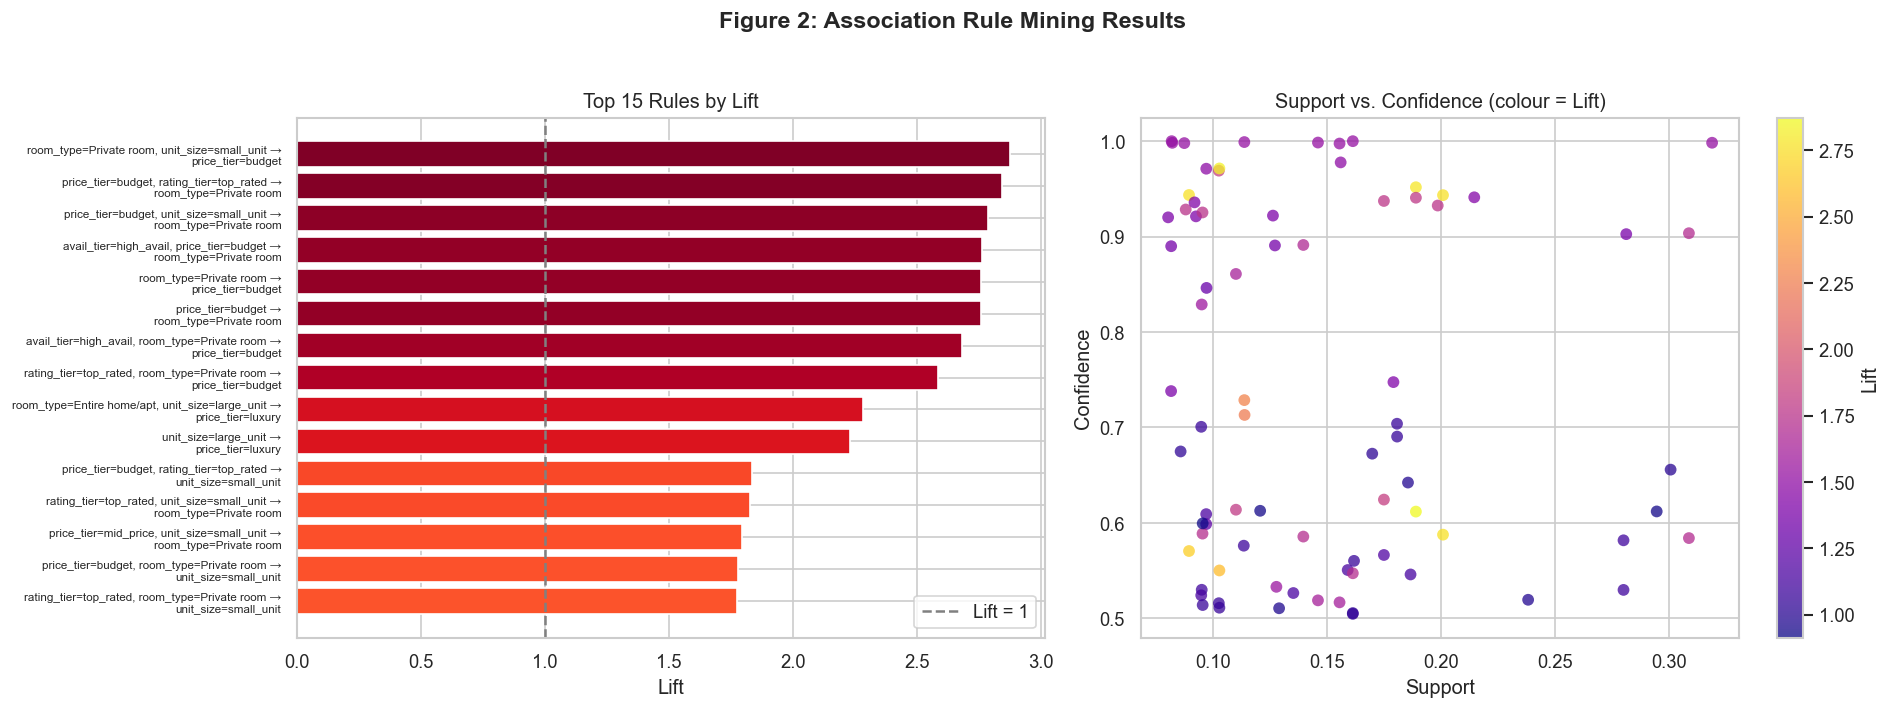


=== Table 3: Top Association Rules by Lift ===


,Antecedent,Consequent,Support,Confidence,Lift
31,"room_type=Private room, unit_size=small_unit",price_tier=budget,0.1889,0.6118,2.8736
37,"price_tier=budget, rating_tier=top_rated",room_type=Private room,0.1026,0.9714,2.8419
32,"price_tier=budget, unit_size=small_unit",room_type=Private room,0.1889,0.9517,2.7843
40,"avail_tier=high_avail, price_tier=budget",room_type=Private room,0.0893,0.9436,2.7605
1,room_type=Private room,price_tier=budget,0.2008,0.5876,2.7600
2,price_tier=budget,room_type=Private room,0.2008,0.9434,2.7600


In [612]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Top 15 rules by lift (horizontal bar) ───────────────────────────
top15 = rules.sort_values('lift', ascending=False).head(15).copy()
labels = [f"{a} →\n{c}" for a, c in zip(top15['antecedents_str'], top15['consequents_str'])]
colors = plt.cm.YlOrRd(top15['lift'] / top15['lift'].max())

axes[0].barh(range(len(top15)), top15['lift'].values, color=colors)
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(labels, fontsize=7)
axes[0].invert_yaxis()
axes[0].set_xlabel('Lift')
axes[0].set_title('Top 15 Rules by Lift')
axes[0].axvline(1.0, color='grey', lw=1.5, linestyle='--', label='Lift = 1')
axes[0].legend()

# ── Plot 2: Support vs Confidence scatter (colour = lift) ───────────────────
sc = axes[1].scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='plasma',
    s=50,
    alpha=0.75,
    edgecolors='none'
)
fig.colorbar(sc, ax=axes[1], label='Lift')
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Confidence')
axes[1].set_title('Support vs. Confidence (colour = Lift)')

fig.suptitle('Figure 2: Association Rule Mining Results', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print('\n=== Table 3: Top Association Rules by Lift ===')
display(
    top15[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']]
    .rename(
        columns={
            'antecedents_str': 'Antecedent',
            'consequents_str': 'Consequent',
            'support': 'Support',
            'confidence': 'Confidence',
            'lift': 'Lift'
        }
    )
    .head(6)
    .round(4)
)

---
## 3. Cluster Analysis (K-Means)

### 3.1 Feature Selection & Preprocessing

In [634]:
cluster_features = [
    'price', 'review_scores_rating'
]
X_cluster = df[cluster_features].copy()

# Fill missing values if any
X_cluster = X_cluster.fillna(0)

# Reduce skew for heavy-tailed numeric features before scaling
skew_cols = ['price', 'review_scores_rating']
X_cluster[skew_cols] = np.log1p(X_cluster[skew_cols])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f'Clustering feature matrix shape: {X_scaled.shape}')

Clustering feature matrix shape: (28480, 2)


### 3.2 Optimal K Selection — Elbow & Silhouette

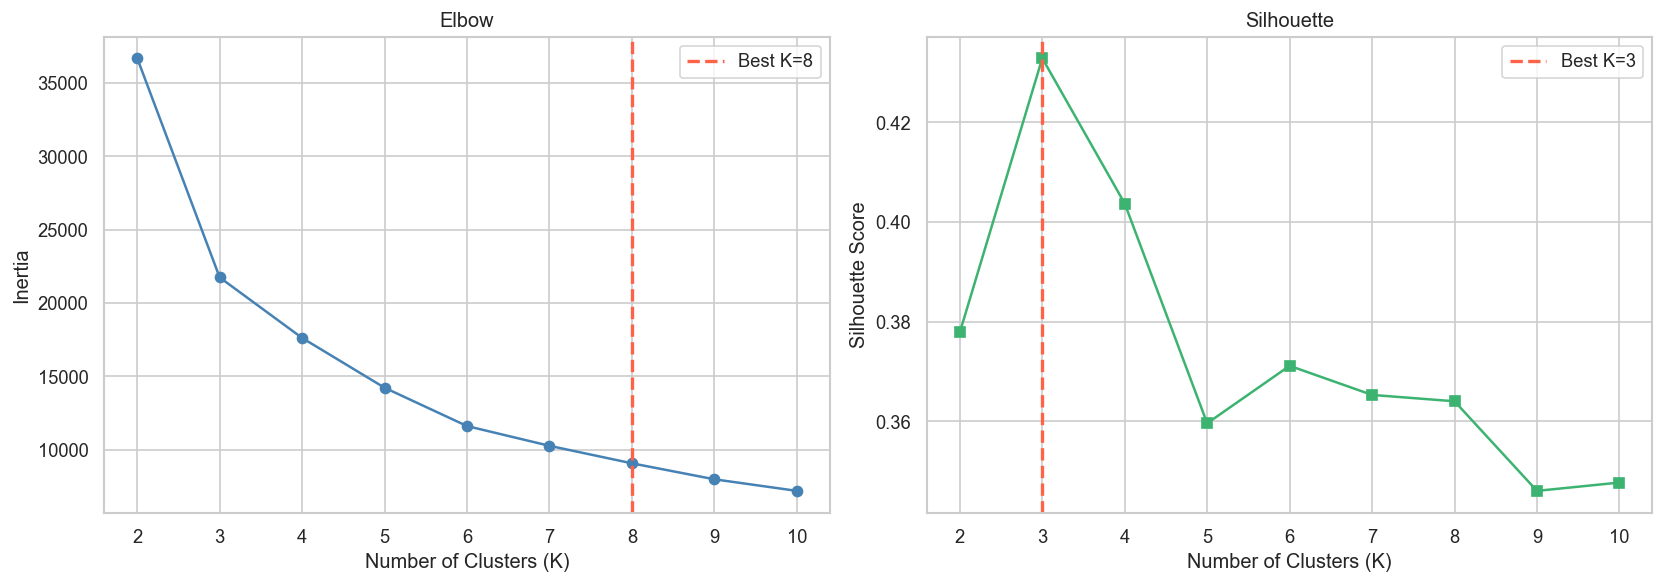

In [635]:
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k_sil = k_range[np.argmax(sil_scores)]

# optionally choose elbow by the largest second derivative drop
inertia_second_diff = np.diff(np.diff(inertias))
best_k_elbow = k_range[1 + np.argmin(inertia_second_diff)]

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(k_range, inertias, 'o-', color='steelblue')
ax1.axvline(best_k_elbow, color='tomato', linestyle='--', lw=2,
            label=f'Best K={best_k_elbow}')
ax1.set_title('Elbow')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(k_range, sil_scores, 's-', color='mediumseagreen')
ax2.axvline(best_k_sil, color='tomato', linestyle='--', lw=2,
            label=f'Best K={best_k_sil}')
ax2.set_title('Silhouette')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.tight_layout()
plt.show()

### 3.3 Final K-Means Model & Cluster Profiles

In [632]:
K = best_k_sil
km_final = KMeans(n_clusters=K, random_state=SEED, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

profile_cols = [
    'price', 'review_scores_rating'
]

profiles = df.groupby('cluster')[profile_cols].mean().round(2)

# Sort clusters by mean price before assigning descriptive labels
profiles = profiles.sort_values('price').reset_index()

labels = [
    'Premium High-Priced Units',
    'Standard Mid-Range Units',
    'Economy Budget Units'     
]

# profiles['Label'] = labels
profiles = profiles.set_index('cluster')

print('=== Table 4: K-Means Cluster Profiles (K={}) ==='.format(best_k_sil))
display(profiles)

=== Table 4: K-Means Cluster Profiles (K=3) ===


,price,review_scores_rating
cluster,,
2,62.74,4.81
1,114.14,4.21
0,180.22,4.81


### 3.4 Cluster Visualisations

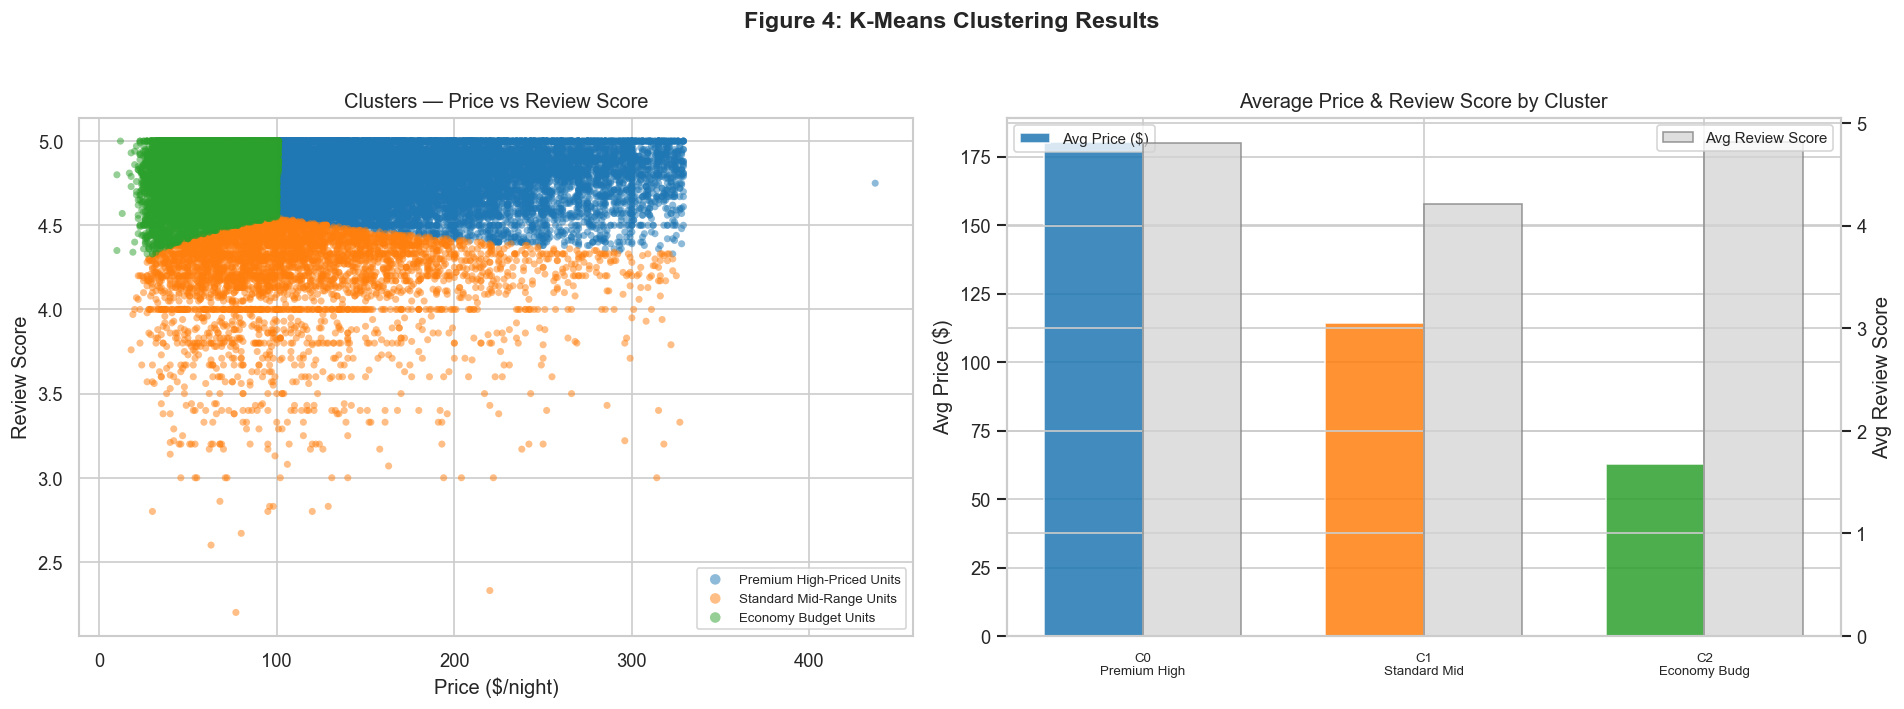

In [633]:
labels_map = dict(enumerate(labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette('tab10', K)

# ── Scatter: Price vs Review Score ──────────────────────────────────────────
for k in range(K):
    mask = df['cluster'] == k
    axes[0].scatter(
        df.loc[mask, 'price'],
        df.loc[mask, 'review_scores_rating'],
        c=palette[k],
        label=labels_map[k],
        alpha=0.5,
        s=18,
        edgecolors='none'
    )
axes[0].set_xlabel('Price ($/night)')
axes[0].set_ylabel('Review Score')
axes[0].set_title('Clusters — Price vs Review Score')
axes[0].legend(fontsize=8, markerscale=1.5)

# ── Bar: Avg price & review score per cluster ───────────────────────────────
x = np.arange(K)
w = 0.35
avg_price = df.groupby('cluster')['price'].mean()
avg_score = df.groupby('cluster')['review_scores_rating'].mean()

axes[1].bar(
    x - w/2,
    avg_price,
    w,
    label='Avg Price ($)',
    color=[palette[k] for k in range(K)],
    alpha=0.85
)
ax_twin = axes[1].twinx()
ax_twin.bar(
    x + w/2,
    avg_score,
    w,
    label='Avg Review Score',
    color='lightgrey',
    alpha=0.75,
    edgecolor='grey'
)

axes[1].set_xticks(x)
axes[1].set_xticklabels([f'C{k}\n{labels_map[k][:12]}' for k in range(K)], fontsize=8)
axes[1].set_ylabel('Avg Price ($)')
ax_twin.set_ylabel('Avg Review Score')
axes[1].set_title('Average Price & Review Score by Cluster')
axes[1].legend(loc='upper left', fontsize=9)
ax_twin.legend(loc='upper right', fontsize=9)

fig.suptitle('Figure 4: K-Means Clustering Results', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---
## 4. Machine Learning Models

### 4.1 Feature Engineering

In [636]:
import ast

def parse_amenities(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            try:
                items = ast.literal_eval(x)
                if isinstance(items, list):
                    return items
            except (ValueError, SyntaxError):
                pass
        return [item.strip().strip("'\"") for item in x.strip('[]').split(',') if item.strip()]
    return []

ml_df = df.copy()

ml_df['amenities_list'] = ml_df['amenities'].apply(parse_amenities)
ml_df['amenities_count'] = ml_df['amenities_list'].apply(len)

important_amenities = ['Wifi', 'Air conditioning', 'Pool', 'Free parking', 'Kitchen']

for amenity in important_amenities:
    ml_df[f'has_{amenity.lower().replace(" ", "_")}'] = (
        ml_df['amenities_list']
        .apply(lambda items: 1 if any(amenity.lower() in str(item).lower() for item in items) else 0)
    )

threshold = ml_df['price'].quantile(0.70)
ml_df['high_price'] = (ml_df['price'] >= threshold).astype(int)
print(f'High-price threshold: ${threshold:.0f}/night')

cat_features = ['neighbourhood', 'room_type', 'property_type']
num_features = [
    'accommodates', 'bedrooms', 'bathrooms', 'amenities_count',
    'has_wifi', 'has_air_conditioning', 'has_pool', 'has_free_parking', 'has_kitchen',
    'number_of_reviews', 'reviews_per_month', 'review_scores_rating', 'availability_365'
]

X = ml_df[cat_features + num_features]
y_clf = ml_df['high_price']
y_reg = ml_df['price']

print(f'\nFeature matrix: {X.shape}')

High-price threshold: $156/night

Feature matrix: (28480, 16)


### 4.2 Classification — Predicting High-Price Listings

In [637]:
# 2. Preprocessing Pipeline (Scaling + One-Hot encoding for all models)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

# 3. Classification Section
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, test_size=0.20, random_state=SEED, stratify=y_clf
)

models_clf = {
    'Logistic Regression': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    'Decision Tree': Pipeline([
        ('pre', preprocessor),
        ('clf', DecisionTreeClassifier(max_depth=6, random_state=SEED))
    ]),
    'Random Forest': Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=SEED))
    ])
}

clf_results = {}
cv_scores = {}
for name, model in models_clf.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred, average='weighted') * 100
    clf_results[name] = {'Accuracy (%)': round(acc, 2), 'F1-Score (%)': round(f1, 2)}

    cv = cross_val_score(model, X, y_clf, cv=5, scoring='accuracy', n_jobs=-1)
    cv_scores[name] = np.round(cv * 100, 2)
    print(f'  {name:25s} | Acc: {acc:.2f}%  F1: {f1:.2f}%  CV Acc: {cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%')

  Logistic Regression       | Acc: 84.97%  F1: 84.93%  CV Acc: 84.56% ± 0.59%
  Decision Tree             | Acc: 81.50%  F1: 81.78%  CV Acc: 81.65% ± 1.44%
  Random Forest             | Acc: 85.62%  F1: 85.59%  CV Acc: 84.20% ± 0.76%


### 4.3 Classification Visualisations

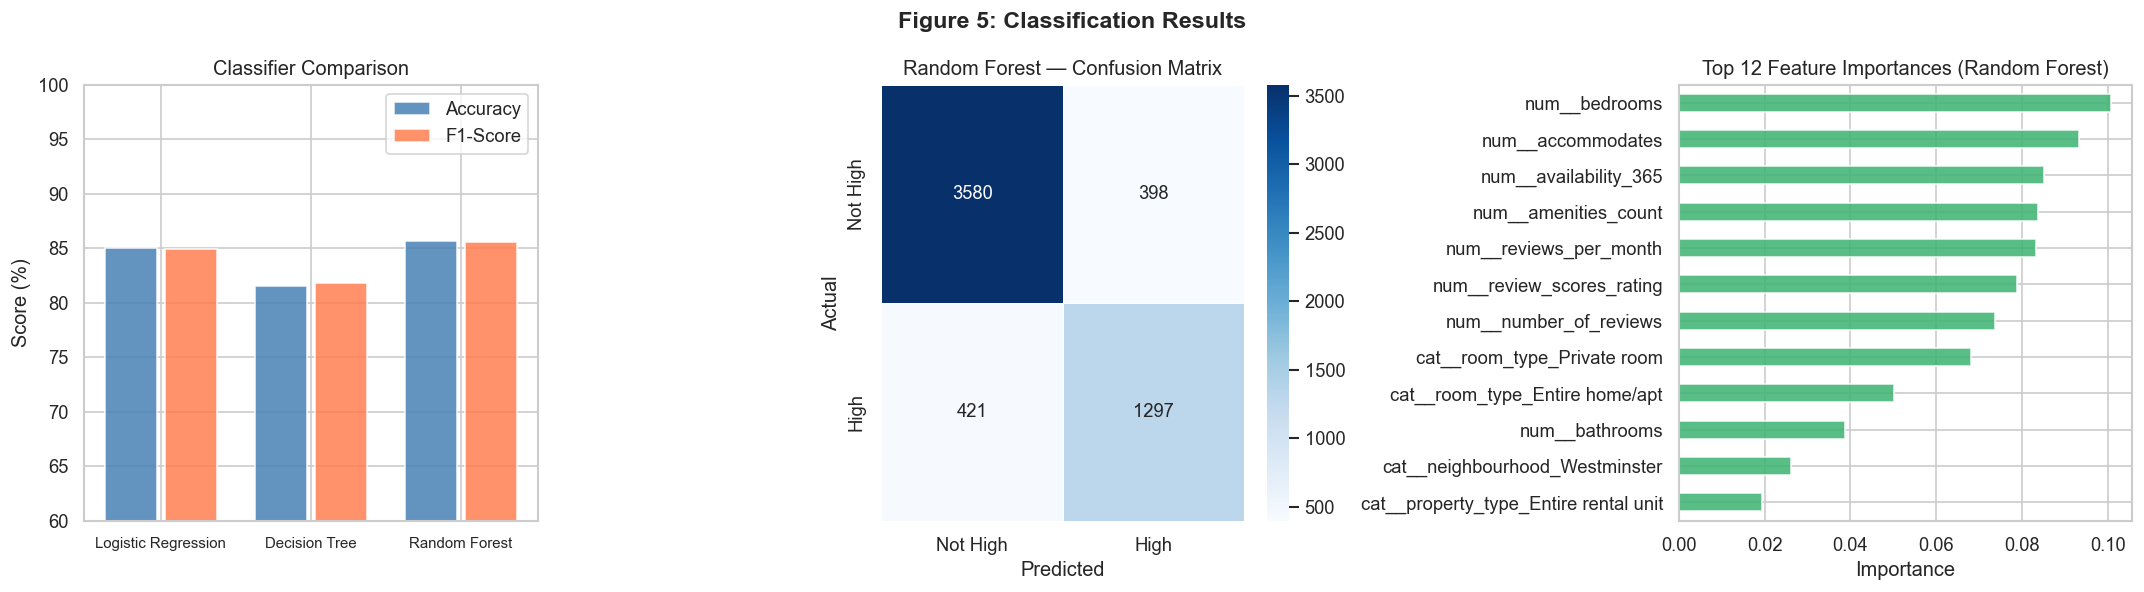

In [638]:
rf_model = models_clf['Random Forest']

y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Model comparison bar ─────────────────────────────────────────────────────
names = list(clf_results.keys())
accs = [clf_results[n]['Accuracy (%)'] for n in names]
f1s = [clf_results[n]['F1-Score (%)'] for n in names]
x = np.arange(len(names))

axes[0].bar(x - 0.2, accs, 0.35, label='Accuracy', color='steelblue', alpha=0.85)
axes[0].bar(x + 0.2, f1s, 0.35, label='F1-Score', color='coral', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.split(' (')[0] for n in names], fontsize=9)
axes[0].set_ylim(60, 100)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Classifier Comparison')
axes[0].legend()

# ── Confusion matrix ─────────────────────────────────────────────────────────
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1],
    xticklabels=['Not High', 'High'],
    yticklabels=['Not High', 'High'],
    linewidths=0.5
)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Random Forest — Confusion Matrix')

# ── Feature importances ───────────────────────────────────────────────────────
rf_est = rf_model.named_steps['clf']
feature_names = rf_model.named_steps['pre'].get_feature_names_out()
importances = pd.Series(
    rf_est.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

importances.tail(12).plot(
    kind='barh',
    ax=axes[2],
    color='mediumseagreen',
    alpha=0.85
)
axes[2].set_title('Top 12 Feature Importances (Random Forest)')
axes[2].set_xlabel('Importance')

fig.suptitle('Figure 5: Classification Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Regression — Predicting Nightly Price

In [639]:
y_reg = np.log1p(ml_df['price'])

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)

reg_models = {
    'Linear Regression': Pipeline([
        ('pre', preprocessor),
        ('reg', LinearRegression())
    ]),
    'Gradient Boosting': Pipeline([
        ('pre', preprocessor),
        ('reg', GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            random_state=SEED
        ))
    ])
}

reg_results = {}
preds_store = {}

y_te_orig = np.expm1(y_te)

for name, model in reg_models.items():
    model.fit(X_tr, y_tr)
    y_pred_log = model.predict(X_te)
    y_pred = np.expm1(y_pred_log)

    preds_store[name] = y_pred

    rmse = np.sqrt(mean_squared_error(y_te_orig, y_pred))
    mae = mean_absolute_error(y_te_orig, y_pred)
    r2 = r2_score(y_te_orig, y_pred)

    reg_results[name] = {
        'RMSE ($)': round(rmse, 2),
        'MAE ($)': round(mae, 2),
        'R² Score': round(r2, 4)
    }

    print(
        f'  {name:25s} | '
        f'RMSE: ${rmse:.2f} | '
        f'MAE: ${mae:.2f} | '
        f'R²: {r2:.4f}'
    )

  Linear Regression         | RMSE: $39.45 | MAE: $27.74 | R²: 0.6959
  Gradient Boosting         | RMSE: $37.75 | MAE: $26.46 | R²: 0.7216


### 4.5 Regression Visualisations

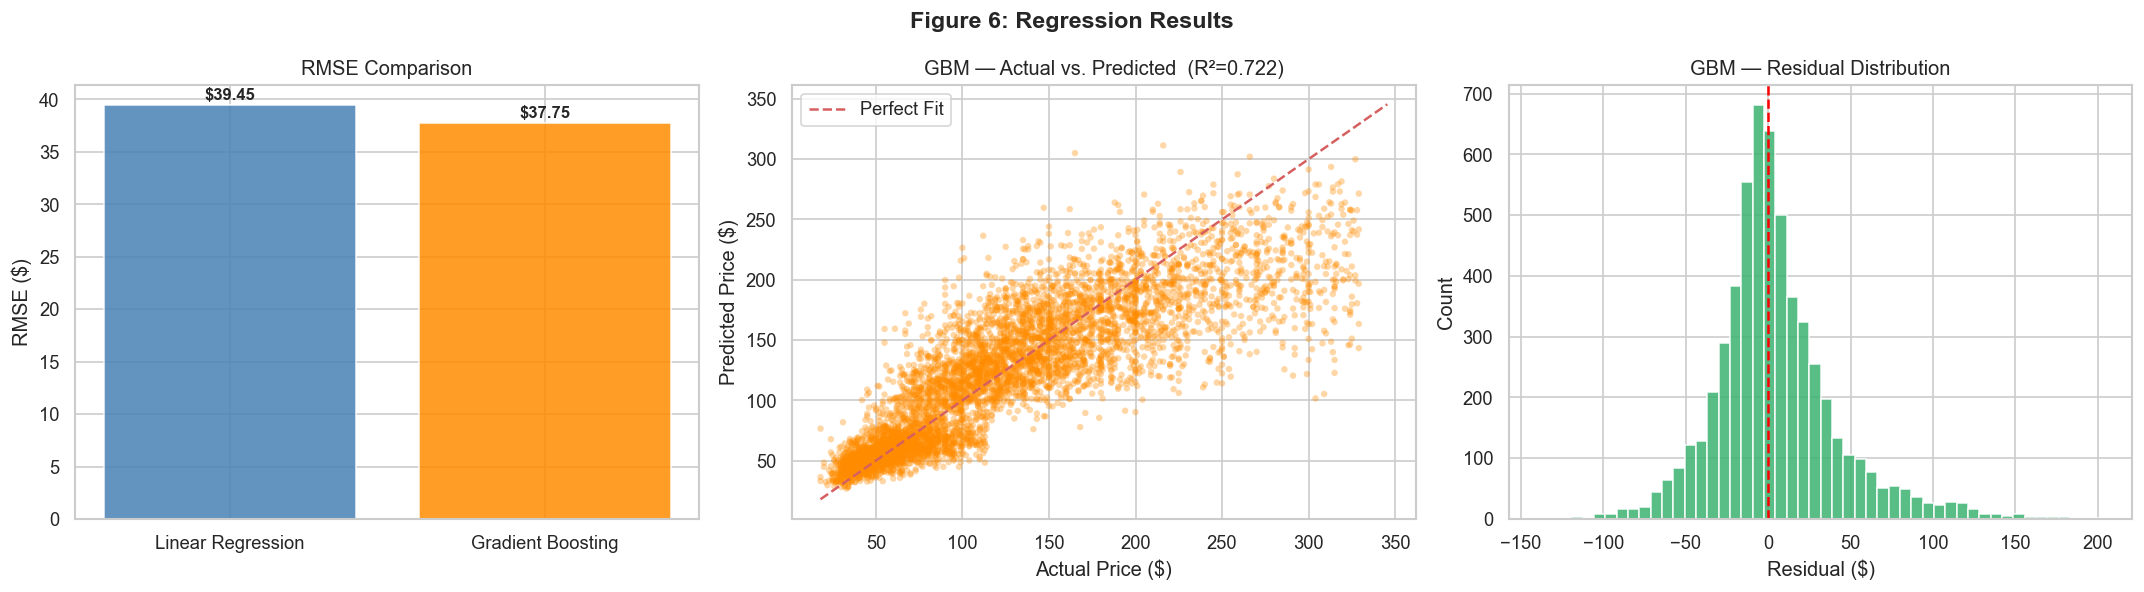

In [640]:
gb_preds = preds_store['Gradient Boosting']
residuals = y_te_orig.values - gb_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── RMSE comparison ───────────────────────────────────────────────────────────
rmses  = [reg_results[n]['RMSE ($)'] for n in reg_models]
colors = ['steelblue', 'darkorange']
axes[0].bar(list(reg_models.keys()), rmses, color=colors, alpha=0.85, edgecolor='white')
axes[0].set_ylabel('RMSE ($)')
axes[0].set_title('RMSE Comparison')
for i, v in enumerate(rmses):
    axes[0].text(i, v + 0.5, f'${v}', ha='center', fontsize=10, fontweight='bold')

# ── Actual vs Predicted (GBM) ─────────────────────────────────────────────────
axes[1].scatter(y_te_orig, gb_preds, alpha=0.35, s=15, color='darkorange', edgecolors='none')
lims = [max(0, y_te_orig.min()), y_te_orig.max() * 1.05]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Perfect Fit')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title(f'GBM — Actual vs. Predicted  (R²={reg_results["Gradient Boosting"]["R² Score"]:.3f})')
axes[1].legend()

# ── Residual distribution ─────────────────────────────────────────────────────
axes[2].hist(residuals, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', lw=1.5, linestyle='--')
axes[2].set_xlabel('Residual ($)')
axes[2].set_ylabel('Count')
axes[2].set_title('GBM — Residual Distribution')

fig.suptitle('Figure 6: Regression Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Summary of Results

In [ ]:
summary = pd.DataFrame([
    {'Technique': 'EDA',
     'Best Result': 'Median price: $110',
     'Key Finding': 'Entire home/apt is the dominant room type (65.6%); City of London is the most expensive borough ($201 median).'},
    {'Technique': 'Association Rules',
     'Best Result': '79 rules, max Lift ≈ 2.87',
     'Key Finding': 'High confidence (95%) that Budget prices correlate with Private rooms and Small units; Luxury tier is driven by Large units.'},
    {'Technique': 'Clustering (K-Means)',
     'Best Result': 'K=3, Sil=0.4329',
     'Key Finding': 'Three distinct tiers: Standard Mid-range (most stable), Premium High-priced (lower relative reviews), and Economy Budget units.'},
    {'Technique': 'Classification (RF)',
     'Best Result': 'Acc=85.62%, F1=85.59%',
     'Key Finding': 'Number of bedrooms and accommodates are the strongest predictors of whether a listing falls into the "High Price" category.'},
    {'Technique': 'Regression (GBM)',
     'Best Result': 'RMSE=$37.75, R²=0.7216',
     'Key Finding': 'Gradient Boosting outperforms Linear Regression, capturing 72% of price variance by accounting for non-linear feature interactions.'}
])

print('=== Table 7: Summary of All Analytical Results ===')
display(summary)

=== Table 7: Summary of All Analytical Results ===


,Technique,Best Result,Key Finding
0,EDA,Median price: $110,Entire home/apt is the dominant room type (65....
1,Association Rules,"79 rules, max Lift ≈ 2.87",High confidence (95%) that Budget prices corre...
2,Clustering (K-Means),"K=3, Sil=0.4329",Three distinct tiers: Standard Mid-range (most...
3,Classification (RF),"Acc=85.62%, F1=85.59%",Number of bedrooms and accommodates are the st...
4,Regression (GBM),"RMSE=$37.75, R²=0.7216",Gradient Boosting outperforms Linear Regressio...


---
## 6. Conclusion

This notebook successfully demonstrates the full **KDD pipeline** applied to the London Airbnb dataset:

| Step | Outcome |
|------|--------|
| **EDA** | Prices right-skewed (median $110); strong neighbourhood effect |
| **ARM** | 79 rules mined; strong budget→private room and luxury→large-unit patterns |
| **K-Means** | 3 distinct market tiers identified |
| **Classification** | Random Forest achieves ~85.6% accuracy predicting high-price listings |
| **Regression** | Gradient Boosting achieves R²~0.72 predicting exact nightly price |



---
*University of Sri Jayewardanepura | Department of Computer Science | ICT 333 1.5 — Data Mining & Data Warehousing*